<a href="https://colab.research.google.com/github/Nurhikmah05-alt/Data-Wrangling-Project1/blob/main/Tugas2_DataWrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library**

Tahap pertama adalah mengimpor library yang dibutuhkan untuk proses manipulasi data.

In [ ]:
import pandas as pd
import numpy as np

**Membaca Dataset**

Dataset dibaca menggunakan pandas kemudian ditampilkan untuk melihat isi awal data.

In [ ]:
df = pd.read_csv('data_tugas 2.csv')
df

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height
0,?,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
1,?,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
2,?,alfa-romero,gas,two,hatchback,94.5,171.2,65.5,52.4
3,164,audi,gas,four,sedan,99.8,176.6,66.2,54.3
4,164,audi,gas,four,sedan,99.4,176.6,66.4,54.3
...,...,...,...,...,...,...,...,...,...
200,95,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
201,95,volvo,gas,four,sedan,109.1,188.8,68.8,55.5
202,95,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
203,95,volvo,diesel,four,sedan,109.1,188.8,68.9,55.5


**Menampilkan Struktur Dataset**

Pemeriksaan awal dilakukan untuk mengetahui jumlah data, tipe variabel, dan statistik deskriptif.

In [ ]:
df.shape

(205, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   normalized-losses  205 non-null    object 
 1   make               201 non-null    object 
 2   bahan-bakar        192 non-null    object 
 3   jumlah-pintu       189 non-null    object 
 4   body-style         193 non-null    object 
 5   wheel-bases        202 non-null    float64
 6   length             197 non-null    float64
 7   width              200 non-null    float64
 8   height             201 non-null    float64
dtypes: float64(4), object(5)
memory usage: 14.5+ KB


In [ ]:
df.describe(include='all')

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height
count,205,201,192,189,193,202.000000,197.000000,200.000000,201.000000
unique,52,22,2,3,5,NaN,NaN,NaN,NaN
top,?,toyota,gas,four,sedan,NaN,NaN,NaN,NaN
freq,41,32,173,101,88,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,98.783663,173.902538,65.931000,53.737313
std,NaN,NaN,NaN,NaN,NaN,6.054592,12.147757,2.136695,2.446620
min,NaN,NaN,NaN,NaN,NaN,86.600000,141.100000,60.300000,47.800000
25%,NaN,NaN,NaN,NaN,NaN,94.500000,166.800000,64.100000,52.000000
50%,NaN,NaN,NaN,NaN,NaN,97.000000,173.200000,65.500000,54.100000
75%,NaN,NaN,NaN,NaN,NaN,102.400000,181.700000,66.900000,55.500000


Output menunjukkan dataset terdiri dari 205 baris dan 9 variabel, dengan beberapa variabel memiliki missing value.

**1. Mengidentifikasi Missing Value**

Simbol seperti tanda tanya dan nilai kosong diubah menjadi NaN agar dapat terdeteksi sebagai missing value.

In [ ]:
df.replace(['?', ' ', ''], np.nan, inplace=True)

In [ ]:
df.isnull().sum()

,0
normalized-losses,41
make,4
bahan-bakar,13
jumlah-pintu,18
body-style,12
wheel-bases,3
length,8
width,5
height,4


Berdasarkan hasil diatas, terlihat bahwa **variabel normalized-losses** memiliki jumlah missing value paling banyak yaitu **41 data**. Selain itu, beberapa variabel kategorik seperti make, bahan-bakar, jumlah-pintu, dan body-style juga memiliki nilai yang hilang. Sedangkan pada variabel numerik, missing value ditemukan pada wheel-bases, length, width, dan height.


**2. Menangani Missing Value Variabel Kategorik**

Missing value pada variabel kategorik diganti dengan kategori baru yaitu `"unknown"` agar data tetap dapat digunakan tanpa menghapus baris.

In [ ]:
categorical_cols = ['make','bahan-bakar','jumlah-pintu','body-style']

for col in categorical_cols:
    df[col] = df[col].fillna('unknown')
df

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height
0,NaN,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
1,NaN,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
2,NaN,alfa-romero,gas,two,hatchback,94.5,171.2,65.5,52.4
3,164,audi,gas,four,sedan,99.8,176.6,66.2,54.3
4,164,audi,gas,four,sedan,99.4,176.6,66.4,54.3
...,...,...,...,...,...,...,...,...,...
200,95,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
201,95,volvo,gas,four,sedan,109.1,188.8,68.8,55.5
202,95,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
203,95,volvo,diesel,four,sedan,109.1,188.8,68.9,55.5


Output menampilkan tabel jumlah masing-masing kategori pada setiap variabel, termasuk kategori baru `"unknown"`.

**3. Imputasi Mean Variabel Numerik (Length, Width, Height)**

Missing value pada variabel numerik diisi menggunakan nilai rata-rata masing-masing kolom.

In [ ]:
numeric_missing = ['length','width','height']

for col in numeric_missing:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())
df

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height
0,NaN,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
1,NaN,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
2,NaN,alfa-romero,gas,two,hatchback,94.5,171.2,65.5,52.4
3,164,audi,gas,four,sedan,99.8,176.6,66.2,54.3
4,164,audi,gas,four,sedan,99.4,176.6,66.4,54.3
...,...,...,...,...,...,...,...,...,...
200,95,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
201,95,volvo,gas,four,sedan,109.1,188.8,68.8,55.5
202,95,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
203,95,volvo,diesel,four,sedan,109.1,188.8,68.9,55.5


**Imputasi Mean Variabel Numerik Lain**

Proses imputasi juga dilakukan pada variabel normalized-losses dan wheel-bases.

In [ ]:
numeric_missing = ['normalized-losses','wheel-bases']

for col in numeric_missing:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    mean_value = df[col].mean()
    df[col] = df[col].fillna(mean_value)
df

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height
0,122.0,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
1,122.0,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
2,122.0,alfa-romero,gas,two,hatchback,94.5,171.2,65.5,52.4
3,164.0,audi,gas,four,sedan,99.8,176.6,66.2,54.3
4,164.0,audi,gas,four,sedan,99.4,176.6,66.4,54.3
...,...,...,...,...,...,...,...,...,...
200,95.0,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
201,95.0,volvo,gas,four,sedan,109.1,188.8,68.8,55.5
202,95.0,volvo,gas,four,sedan,109.1,188.8,68.9,55.5
203,95.0,volvo,diesel,four,sedan,109.1,188.8,68.9,55.5


**4. Min-Max Normalization**

Setelah data bersih, dilakukan normalisasi menggunakan metode Min-Max pada variabel wheel-bases. Metode ini mengubah nilai ke dalam rentang 0 hingga 1. Berikut formulasi dalam metode ini:


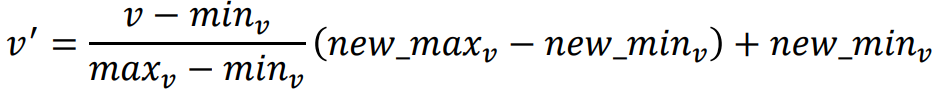


In [ ]:
df['wheel-bases-normalized'] = ((df['wheel-bases'] - df['wheel-bases'].min())/(df['wheel-bases'].max() - df['wheel-bases'].min()))
df

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height,wheel-bases-normalized
0,122.0,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8,0.058309
1,122.0,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8,0.058309
2,122.0,alfa-romero,gas,two,hatchback,94.5,171.2,65.5,52.4,0.230321
3,164.0,audi,gas,four,sedan,99.8,176.6,66.2,54.3,0.384840
4,164.0,audi,gas,four,sedan,99.4,176.6,66.4,54.3,0.373178
...,...,...,...,...,...,...,...,...,...,...
200,95.0,volvo,gas,four,sedan,109.1,188.8,68.9,55.5,0.655977
201,95.0,volvo,gas,four,sedan,109.1,188.8,68.8,55.5,0.655977
202,95.0,volvo,gas,four,sedan,109.1,188.8,68.9,55.5,0.655977
203,95.0,volvo,diesel,four,sedan,109.1,188.8,68.9,55.5,0.655977


Setelah normalisasi Min-Max dilakukan pada variabel wheel-bases, terbentuk kolom baru bernama` wheel-bases-normalized`.

**5. Z-Score Normalization**

Selanjutnya dilakukan standarisasi menggunakan metode Z-score pada variabel length, width, dan height. Metode ini mengubah data sehingga memiliki rata-rata mendekati nol dan standar deviasi sebesar satu, sehingga skala antar variabel menjadi sebanding. Berikut formulasi metode Z-score:

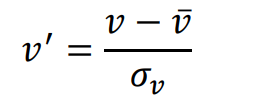

In [ ]:
z_cols = ['length','width','height']

for col in z_cols:
    df[col + '_zscore'] = ((df[col] - df[col].mean()) / df[col].std())
df

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height,wheel-bases-normalized,length_zscore,width_zscore,height_zscore
0,122.0,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8,0.058309,-0.428526,-0.867630,-2.038094
1,122.0,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8,0.058309,-0.428526,-0.867630,-2.038094
2,122.0,alfa-romero,gas,two,hatchback,94.5,171.2,65.5,52.4,0.230321,-0.226967,-0.204232,-0.552035
3,164.0,audi,gas,four,sedan,99.8,176.6,66.2,54.3,0.384840,0.226541,0.127467,0.232274
4,164.0,audi,gas,four,sedan,99.4,176.6,66.4,54.3,0.373178,0.226541,0.222238,0.232274
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,95.0,volvo,gas,four,sedan,109.1,188.8,68.9,55.5,0.655977,1.251132,1.406877,0.727627
201,95.0,volvo,gas,four,sedan,109.1,188.8,68.8,55.5,0.655977,1.251132,1.359492,0.727627
202,95.0,volvo,gas,four,sedan,109.1,188.8,68.9,55.5,0.655977,1.251132,1.406877,0.727627
203,95.0,volvo,diesel,four,sedan,109.1,188.8,68.9,55.5,0.655977,1.251132,1.406877,0.727627


**Pemeriksaan Akhir Missing Value**

Tahap terakhir adalah memastikan bahwa tidak ada lagi missing value pada dataset.

In [ ]:
df.isnull().sum()

,0
normalized-losses,0
make,0
bahan-bakar,0
jumlah-pintu,0
body-style,0
wheel-bases,0
length,0
width,0
height,0
wheel-bases-normalized,0


Output menunjukkan seluruh variabel bernilai 0, yang berarti dataset sudah bersih.

In [ ]:
df.to_csv('hasil_preprocessing_tugas2.csv', index=False)

In [ ]:
df.to_excel('hasil_preprocessing_tugas2.xlsx', index=False)

Setelah melalui tahap data preparation, seluruh missing value berhasil ditangani baik pada variabel kategorik maupun numerik. Selain itu, normalisasi data telah dilakukan menggunakan metode Min-Max dan Z-score. Dengan demikian, dataset sudah bersih, terstandarisasi, dan siap digunakan untuk proses analisis lanjutan maupun pemodelan machine learning. baru tambahkan datanya cocok digunakan untuk apa